# Assignment 02 : Object Detection
Nama: Gracella Wiendy Koesnadi

NIM: 24/541739/PA/22991

Implement one of the object detection methods to solve certain problem without using library. Give analysis of your results in term of accuracy and IoU.



---

Problem: Fruit Detection and Classification

Tujuan: Menggunakan sliding window untuk mendeteksi buah-buahan

In [127]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

#Configuration

In [128]:
TEMPLATE_SIZE = (128, 128)
TRAIN_DIR     = "dataset"
SCENE_PATH    = "buah2.jpg"

WIN_SIZES  = [128]   # ukuran sliding window
STRIDE     = 15              # langkah sliding window
THRESHOLD  = 0.5            # threshold minimum score deteksi
NMS_IOU    = 0.4             # IoU threshold untuk NMS

COLOR_MAP = {
    "apple" : (255,   0,   0),
    "banana": (255, 255,   0),
    "orange": (255, 165,   0),
}

#Load Dataset

In [129]:
import gdown, zipfile
gdrive_folder_id = "1GYQQ-dmktRRu75IatDIvpuzknJa2RCyY"
IMAGE_LIMIT = 50
os.makedirs(TRAIN_DIR, exist_ok=True)
gdown.download_folder(id=gdrive_folder_id, output="dataset", quiet=False, remaining_ok=True)
for filename in os.listdir("dataset"):
    if filename.endswith(".zip"):
        with zipfile.ZipFile(os.path.join("dataset", filename), "r") as z:
            z.extractall("dataset")
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")
all_images = [f for f in os.listdir(TRAIN_DIR) if f.lower().endswith(image_extensions)]
for img in all_images[IMAGE_LIMIT:]:
    os.remove(os.path.join(TRAIN_DIR, img))
print(f"Dataset limited to {min(len(all_images), IMAGE_LIMIT)} images.")

# Define Function

In [130]:
def preprocess(image: np.ndarray) -> np.ndarray:
    """Resize ke TEMPLATE_SIZE lalu histogram-equalize (untuk gambar template)."""
    resized   = cv2.resize(image, TEMPLATE_SIZE)
    return resized

def preprocess_window(window: np.ndarray) -> np.ndarray:
    """Histogram-equalize window yang sudah berukuran tepat."""
    return cv2.equalizeHist(window)

In [131]:
def load_scene(path: str):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Scene image not found: {path}")
    img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_eq   = cv2.equalizeHist(img_gray)
    return img_rgb, img_gray, img_eq

def draw_detections(img_rgb: np.ndarray, detections: list) -> np.ndarray:
    result = img_rgb.copy()
    for d in detections:
        x, y, w, h = d["x"], d["y"], d["w"], d["h"]
        color = COLOR_MAP.get(d["kelas"], (255, 255, 255))
        cv2.rectangle(result, (x, y), (x + w, y + h), color, 2)
        cv2.putText(result,
                    f"{d['kelas']} {d['score']}",
                    (x, max(y - 5, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
    return result

In [132]:
def nms(detections: list, iou_threshold: float = 0.3) -> list:
    if not detections:
        return []

    boxes   = np.array([[d["x"], d["y"], d["x"]+d["w"], d["y"]+d["h"]]
                         for d in detections], dtype=float)
    scores  = np.array([d["score"] for d in detections])
    indices = np.argsort(scores)[::-1]

    kept = []
    while len(indices) > 0:
        i = indices[0]
        kept.append(i)
        if len(indices) == 1:
            break

        xx1 = np.maximum(boxes[i, 0], boxes[indices[1:], 0])
        yy1 = np.maximum(boxes[i, 1], boxes[indices[1:], 1])
        xx2 = np.minimum(boxes[i, 2], boxes[indices[1:], 2])
        yy2 = np.minimum(boxes[i, 3], boxes[indices[1:], 3])

        inter   = np.maximum(0, xx2 - xx1) * np.maximum(0, yy2 - yy1)
        area_i  = (boxes[i, 2]-boxes[i, 0]) * (boxes[i, 3]-boxes[i, 1])
        area_j  = ((boxes[indices[1:], 2]-boxes[indices[1:], 0]) *
                   (boxes[indices[1:], 3]-boxes[indices[1:], 1]))
        iou     = inter / (area_i + area_j - inter + 1e-6)

        indices = indices[1:][iou < iou_threshold]

    return [detections[i] for i in kept]

# Perform Sliding Window


In [133]:
def sliding_window(image: np.ndarray, win_h: int, win_w: int, stride: int):
    for y in range(0, image.shape[0] - win_h + 1, stride):
        for x in range(0, image.shape[1] - win_w + 1, stride):
            yield (x, y, image[y:y + win_h, x:x + win_w])


def match_templates_sliding_window(
        scene: np.ndarray,
        template_dict: dict,
        win_sizes: list = WIN_SIZES,
        stride:    int  = STRIDE,
        threshold: float = THRESHOLD,
) -> list:
    detections = []

    for win_size in win_sizes:
        win_h = win_w = win_size

        for (x, y, window) in sliding_window(scene, win_h, win_w, stride):
            if window.shape[0] != win_h or window.shape[1] != win_w:
                continue

            window_resized = cv2.resize(window, TEMPLATE_SIZE)
            window_proc    = preprocess_window(window_resized)

            best_score = -1.0
            best_kelas = None

            for kelas, templates in template_dict.items():
                scores = []
                for tpl in templates:
                    T      = tpl["image"]
                    result = cv2.matchTemplate(window_proc, T,
                                               cv2.TM_CCOEFF_NORMED)
                    scores.append(float(result[0, 0]))

                top_scores = sorted(scores, reverse=True)[:3]
                avg_score  = float(np.mean(top_scores))

                if avg_score > best_score:
                    best_score = avg_score
                    best_kelas = kelas

            if best_score >= threshold:
                detections.append({
                    "kelas": best_kelas,
                    "score": round(best_score, 4),
                    "x": x, "y": y, "w": win_w, "h": win_h,
                })

    return detections

In [134]:
def load_templates(train_dir: str) -> dict:
    raw_dict = {}
    for filename in sorted(os.listdir(train_dir)):
        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        kelas    = filename.rsplit("_", 1)[0]
        img_path = os.path.join(train_dir, filename)
        tpl      = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if tpl is None:
            print(f"  [WARN] Tidak bisa membaca {img_path}, dilewati.")
            continue
        raw_dict.setdefault(kelas, []).append(
            {"image": tpl, "filename": filename}
        )

    processed_dict = {}
    for kelas, templates_list in raw_dict.items():
        processed_dict[kelas] = [
            {"image": preprocess(t["image"]), "filename": t["filename"]}
            for t in templates_list
        ]
        print(f"  {kelas}: {len(processed_dict[kelas])} template(s) dimuat")

    return processed_dict

Memuat scene: buah2.jpg


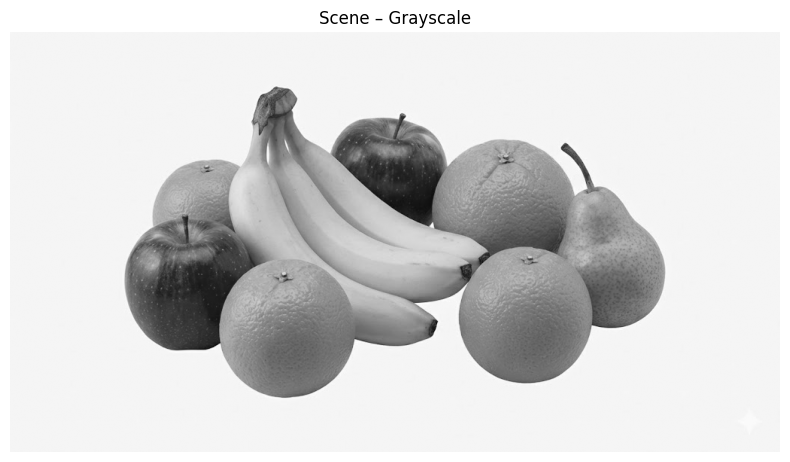

In [135]:
print(f"Memuat scene: {SCENE_PATH}")
img_rgb, img_gray, img_eq = load_scene(SCENE_PATH)

plt.figure(figsize=(8, 6))
plt.imshow(img_gray, cmap="gray")
plt.title("Scene – Grayscale")
plt.axis("off")
plt.tight_layout()
plt.show()

In [136]:
template_dict = load_templates(TRAIN_DIR)

if not template_dict:
    raise RuntimeError(
        "[ERROR] Tidak ada template yang dimuat. "
        "Pastikan TRAIN_DIR ada dan berisi gambar."
    )

Memuat template dari: dataset
  apple: 20 template(s) dimuat
  banana: 15 template(s) dimuat
  orange: 15 template(s) dimuat


In [144]:
detections_raw = match_templates_sliding_window(
    scene         = img_eq,
    template_dict = template_dict,
    win_sizes     = WIN_SIZES,
    stride        = STRIDE,
    threshold     = THRESHOLD,
)

In [143]:
detections = nms(detections_raw, iou_threshold=NMS_IOU)
print(f"Deteksi setelah NMS : {len(detections)}")

Deteksi setelah NMS : 10


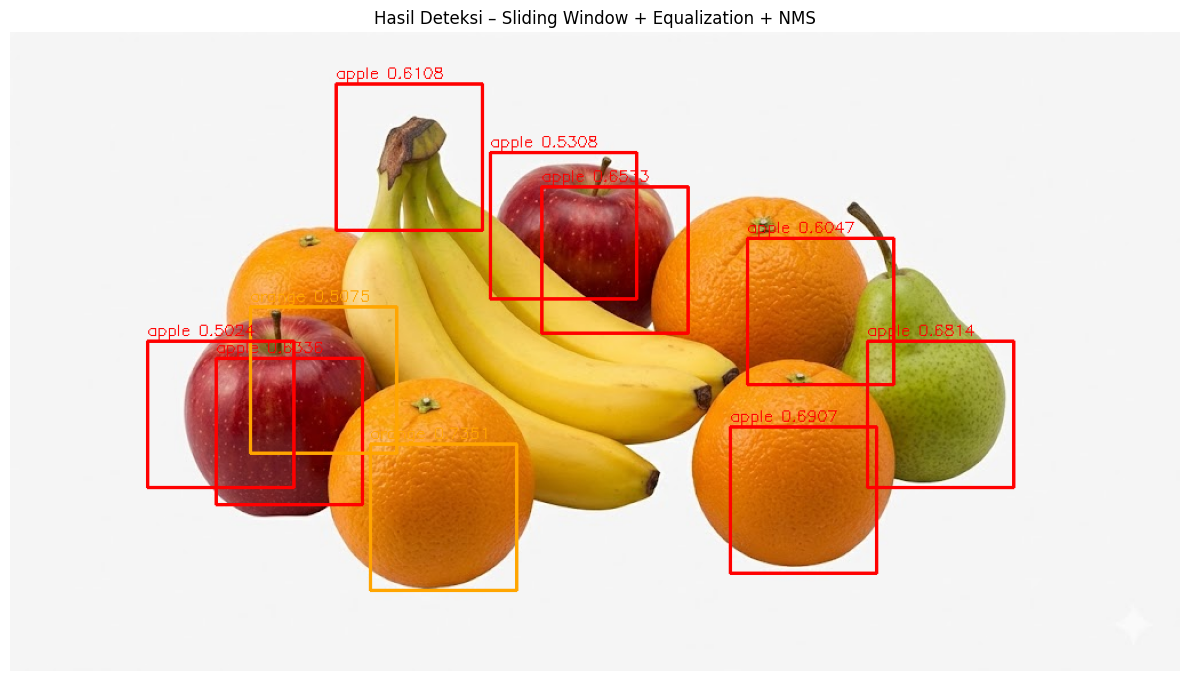

In [139]:
img_result = draw_detections(img_rgb, detections)

plt.figure(figsize=(12, 9))
plt.imshow(img_result)
plt.title("Hasil Deteksi – Sliding Window + Equalization + NMS")
plt.axis("off")
plt.tight_layout()
plt.show()

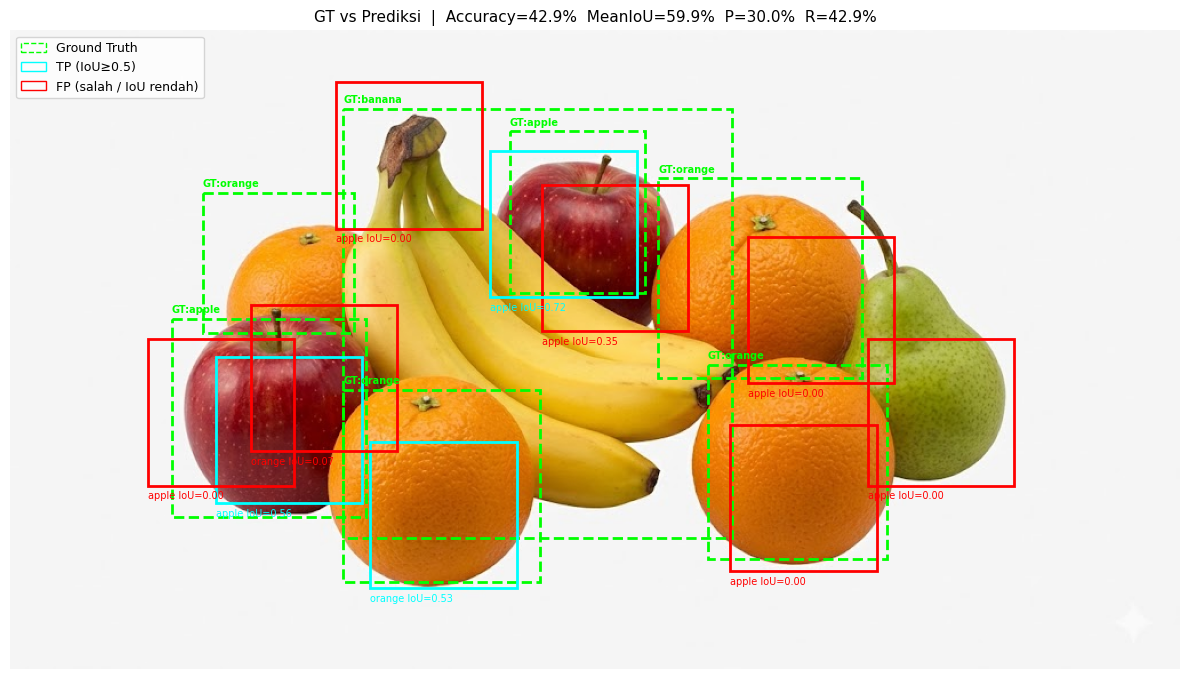


IoU per kelas:
  Mean IoU      : 0.5993  (59.93%)
  Precision     : 0.3000  (30.00%)
  Recall        : 0.4286  (42.86%)
  F1-Score      : 0.3529
  Accuracy      : 0.4286  (42.86%)


In [142]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

COCO_PATH = "_annotations.coco.json"  # sesuaikan path jika perlu

with open(COCO_PATH) as f:
    coco = json.load(f)

# Buat mapping category_id -> nama kelas
cat_map = {c["id"]: c["name"] for c in coco["categories"]}

# Ambil ground truth boxes (format COCO bbox: [x, y, w, h])
gt_boxes = []
for ann in coco["annotations"]:
    kelas = cat_map[ann["category_id"]]
    x, y, w, h = ann["bbox"]
    # Convert x, y, w, h to float
    gt_boxes.append({"kelas": kelas, "x": float(x), "y": float(y), "w": float(w), "h": float(h)})

def compute_iou(boxA, boxB):
    ax1, ay1 = boxA["x"], boxA["y"]
    ax2, ay2 = ax1 + boxA["w"], ay1 + boxA["h"]

    bx1, by1 = boxB["x"], boxB["y"]
    bx2, by2 = bx1 + boxB["w"], by1 + boxB["h"]

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    area_a = boxA["w"] * boxA["h"]
    area_b = boxB["w"] * boxB["h"]
    union_area = area_a + area_b - inter_area

    return inter_area / union_area if union_area > 0 else 0.0

IOU_THRESHOLD = 0.5   # threshold untuk dianggap True Positive

results = []          # detail per prediksi
matched_gt = set()    # index GT yang sudah di-match

for pred in detections:
    best_iou  = 0.0
    best_gt_i = -1

    for i, gt in enumerate(gt_boxes):
        if i in matched_gt:
            continue
        # Class harus cocok
        if pred["kelas"] != gt["kelas"]:
            continue
        iou = compute_iou(pred, gt)
        if iou > best_iou:
            best_iou  = iou
            best_gt_i = i

    if best_iou >= IOU_THRESHOLD:
        matched_gt.add(best_gt_i)
        results.append({"pred": pred, "gt": gt_boxes[best_gt_i],
                         "iou": best_iou, "status": "TP"})
    else:
        results.append({"pred": pred, "gt": None,
                         "iou": best_iou, "status": "FP"})

# GT yang tidak ter-match = False Negative
fn_list = [gt_boxes[i] for i in range(len(gt_boxes)) if i not in matched_gt]


tp_results = [r for r in results if r["status"] == "TP"]
fp_results = [r for r in results if r["status"] == "FP"]

TP = len(tp_results)
FP = len(fp_results)
FN = len(fn_list)

precision  = TP / (TP + FP) if (TP + FP) > 0 else 0
recall     = TP / (TP + FN) if (TP + FN) > 0 else 0
f1         = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
accuracy   = TP / len(gt_boxes) if len(gt_boxes) > 0 else 0
mean_iou   = np.mean([r["iou"] for r in tp_results]) if tp_results else 0


fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.imshow(img_rgb)

for g in gt_boxes:
    rect = mpatches.Rectangle(
        (g["x"], g["y"]), g["w"], g["h"],
        linewidth=2, edgecolor="lime", facecolor="none", linestyle="--"
    )
    ax.add_patch(rect)
    ax.text(g["x"], g["y"] - 5, f"GT:{g['kelas']}",
            color="lime", fontsize=7, fontweight="bold")

for r in results:
    p = r["pred"]
    color = "cyan" if r["status"] == "TP" else "red"
    rect = mpatches.Rectangle(
        (p["x"], p["y"]), p["w"], p["h"],
        linewidth=2, edgecolor=color, facecolor="none"
    )
    ax.add_patch(rect)
    label = f"{p['kelas']} IoU={r['iou']:.2f}"
    ax.text(p["x"], p["y"] + p["h"] + 12, label,
            color=color, fontsize=7)

legend_elements = [
    mpatches.Patch(edgecolor="lime",  facecolor="none", linestyle="--", label="Ground Truth"),
    mpatches.Patch(edgecolor="cyan",  facecolor="none", label=f"TP (IoU≥{IOU_THRESHOLD})"),
    mpatches.Patch(edgecolor="red",   facecolor="none", label="FP (salah / IoU rendah)"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)
ax.set_title(
    f"GT vs Prediksi  |  Accuracy={accuracy*100:.1f}%  MeanIoU={mean_iou*100:.1f}%  "
    f"P={precision*100:.1f}%  R={recall*100:.1f}%",
    fontsize=11
)
ax.axis("off")
plt.tight_layout()
plt.show()

kelas_list = ["apple", "banana", "orange"]
print("\nIoU per kelas:")
iou_per_kelas = {}
for kls in kelas_list:
    tp_k = [r["iou"] for r in tp_results if r["pred"]["kelas"] == kls]
    gt_k = [g for g in gt_boxes if g["kelas"] == kls]
    pred_k = [r for r in results if r["pred"]["kelas"] == kls]
    tp_k_n = len(tp_k)
    fp_k_n = len([r for r in fp_results if r["pred"]["kelas"] == kls])
    fn_k_n = len(gt_k) - tp_k_n
    miou_k = np.mean(tp_k) if tp_k else 0
    iou_per_kelas[kls] = miou_k

print(f"  Mean IoU      : {mean_iou:.4f}  ({mean_iou*100:.2f}%)")
print(f"  Precision     : {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall        : {recall:.4f}  ({recall*100:.2f}%)")
print(f"  F1-Score      : {f1:.4f}")
print(f"  Accuracy      : {accuracy:.4f}  ({accuracy*100:.2f}%)")


Pembahasan:

IoU merupakan metrik untuk melihat seberapa akurat bounding box yang diciptakan. Berdasarkan nilai IoU yang didapatkan, dapat diketahui bahwa status benar (TP) sekitar 60%, di mana bounding box yang menutupi area objek sekitar 60%. Artinya, algoritma mampu menebak dengan benar.

Namun, dari visualisasi, dapat dilihat bahwa masih banyak bounding box yang tidak menutupi satu area objek. Ketika bounding boxnya kecil, masih dianggap "apel" karena template apel memang merah.

Hasil akurasi menunjukkan 0.4 yang artinya akurasinya masih sangat rendah. Model masih terlalu sensitif dan seringkali salah deteksi karena warna yang sama atau hal lainnya.

Sebagai solusi, dapat dicoba untuk multi-scale template agar dapat membuat bounding box yang lebih akurat.